# Notebook 2 — Analyse exploratoire
## Problématique : Dans quelle mesure le passage à l'A320neo réduit-il les émissions CO₂ ?

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/a320_clean.csv')

df.shape

(36496, 12)

In [28]:
df.groupby('type_appareil')['co2'].mean()
df.groupby('type_appareil')['co2'].mean().round(0)

type_appareil
ceo    1409828.0
neo     962856.0
Name: co2, dtype: float64

In [29]:
co2_moyen = df.groupby('type_appareil')['co2'].mean()
co2_ceo = co2_moyen['ceo']
co2_neo = co2_moyen['neo']

print(co2_ceo)
print(co2_neo)

1409828.0135086535
962856.3187847711


In [30]:
reduction = (co2_ceo - co2_neo) / co2_ceo * 100
print(f"Le neo émet {reduction:.1f}% de CO₂ en moins que le ceo")

Le neo émet 31.7% de CO₂ en moins que le ceo


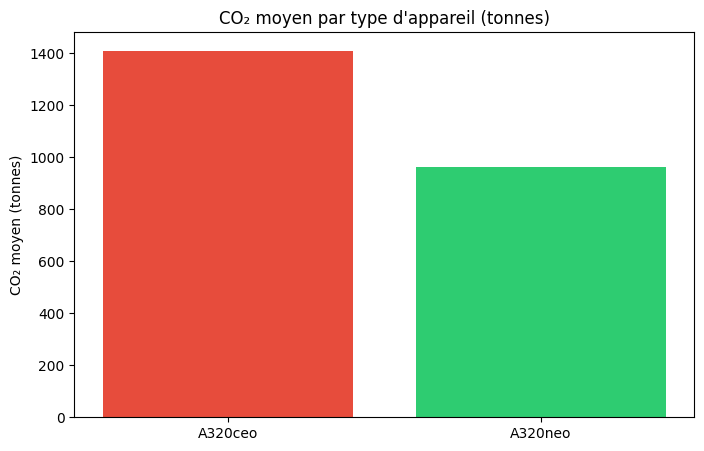

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(['A320ceo', 'A320neo'], [co2_ceo/1000, co2_neo/1000], color=['#e74c3c', '#2ecc71'])
plt.title('CO₂ moyen par type d\'appareil (tonnes)')
plt.ylabel('CO₂ moyen (tonnes)')
plt.show()

> **Note** : Les valeurs de CO₂ représentent le total des émissions par route (cumul de tous les vols), et non les émissions d'un vol unique.

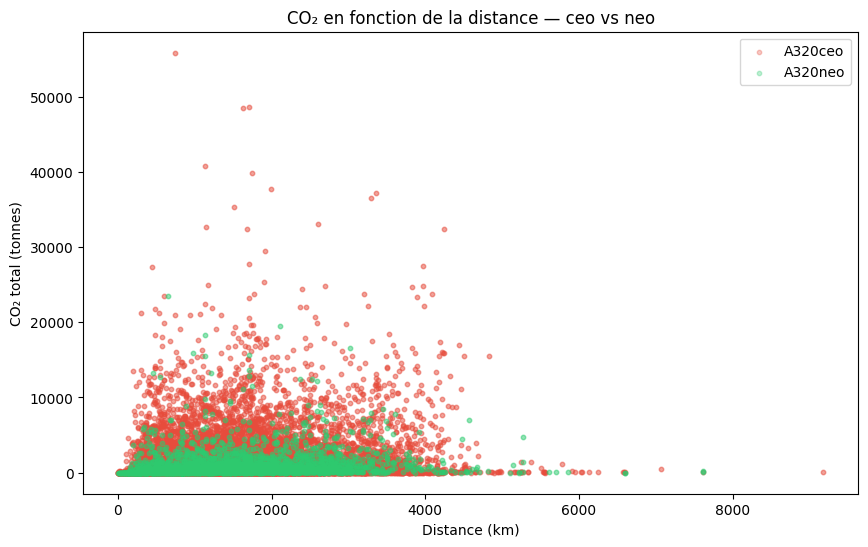

In [32]:
plt.figure(figsize=(10, 6))

ceo = df[df['type_appareil'] == 'ceo']
neo = df[df['type_appareil'] == 'neo']

plt.scatter(ceo['distance_km'], ceo['co2']/1000, color='#e74c3c', alpha=0.3, label='A320ceo', s=10)
plt.scatter(neo['distance_km'], neo['co2']/1000, color='#2ecc71', alpha=0.3, label='A320neo', s=10)

plt.title('CO₂ en fonction de la distance — ceo vs neo')
plt.xlabel('Distance (km)')
plt.ylabel('CO₂ total (tonnes)')
plt.legend()
plt.show()

### Insight 3 : CO₂ vs Distance
- Le **ceo** (rouge) émet systématiquement plus de CO₂ que le **neo** (vert) à distance équivalente.
- Le neo reste minoritaire sur l'ensemble des routes, confirmant sa part de seulement 15.7% de la flotte.
- Les routes courtes et moyennes (< 3 000 km) concentrent le plus de trafic et les émissions les plus élevées : c'est là que le remplacement ceo → neo aurait le plus grand impact.

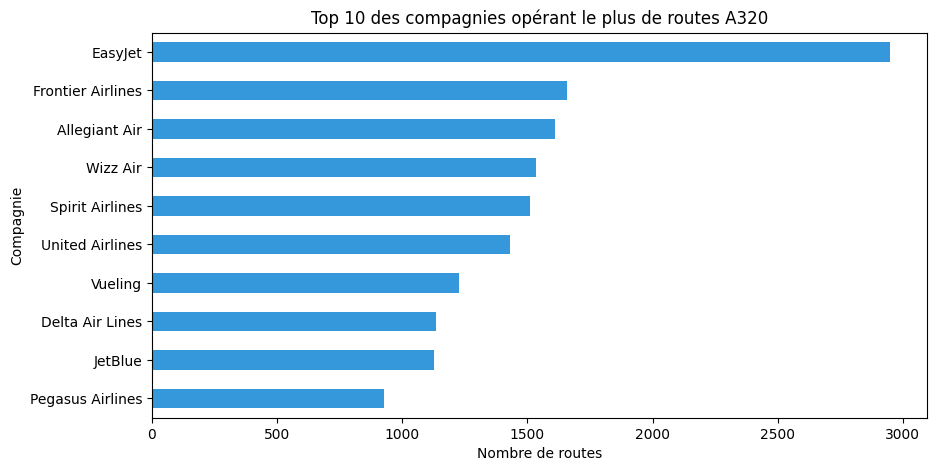

In [33]:
noms = {
    'U2': 'EasyJet',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'W6': 'Wizz Air',
    'NK': 'Spirit Airlines',
    'UA': 'United Airlines',
    'VY': 'Vueling',
    'DL': 'Delta Air Lines',
    'B6': 'JetBlue',
    'PC': 'Pegasus Airlines'
}
df_filtre = df[df['airline_iata'] != 'ZZZ']
top10 = df_filtre['airline_iata'].value_counts().head(10)
top10.index = [noms.get(code, code) for code in top10.index]

plt.figure(figsize=(10, 5))
top10.plot(kind='barh', color='#3498db')
plt.title('Top 10 des compagnies opérant le plus de routes A320')
plt.xlabel('Nombre de routes')
plt.ylabel('Compagnie')
plt.gca().invert_yaxis()
plt.show()

### Insight 4 : Compagnies 
- **EasyJet** est le plus gros opérateur A320 du dataset (~3 000 routes).
- Le top 10 est dominé par les compagnies **low-cost**, principales utilisatrices de l'A320.
- Ces compagnies à fort volume seraient les premières à cibler pour maximiser l'impact d'une transition ceo → neo.